# Mecanismo de Atencion y Transformer para Prediccion de Series de Tiempo

**Dataset:** Airline Passengers — pasajeros mensuales 1949-1960

**Modelos:** LSTM vs Atencion simple vs Transformer simplificado

**Framework:** TensorFlow / Keras

**Flujo del notebook:**
1. Explicacion conceptual: atencion y Transformers
2. Preparacion de datos
3. Modelo A — LSTM (baseline de comparacion)
4. Modelo B — RNN + Mecanismo de Atencion
5. Modelo C — Transformer simplificado
6. Evaluacion comparativa con metricas
7. Visualizacion de pesos de atencion
8. Analisis de dependencias corto/largo plazo
9. Conclusiones

---

## 1. Mecanismo de Atencion y Transformers

### El problema de las RNN

Las RNN/LSTM comprimen toda la historia en un vector de estado oculto fijo.
Para secuencias largas, la informacion de pasos lejanos se diluye — incluso LSTM
tiene dificultades con dependencias muy largas.

### Mecanismo de Atencion

La atencion permite al modelo acceder directamente a todos los pasos pasados
y asignarles un peso segun su relevancia para la prediccion actual:


Donde **Q** (Query), **K** (Key) y **V** (Value) son proyecciones lineales
de la secuencia de entrada.

### Transformer

El Transformer elimina por completo la recurrencia y usa Multi-Head Self-Attention multiples cabezas de atencion en paralelo que capturan diferentes tipos de dependencias. Se agrega:
- **Positional Encoding:** inyecta informacion del orden temporal (sin la cual
  el Transformer no sabe que elemento va antes o despues)
- **Feed-Forward Network:** capa densa por posicion
- **Residual connections + LayerNorm:** estabilizan el entrenamiento


### Ventaja clave vs RNN
| Aspecto | RNN/LSTM | Transformer |
|---------|----------|-------------|
| Acceso al pasado | Secuencial (estado oculto) | Directo (atencion a todos los pasos) |
| Dependencias largas | Limitado (vanishing gradient) | Sin limitacion teorica |
| Paralelizacion | No (secuencial) | Si (todos los pasos a la vez) |
| Interpretabilidad | Baja | Alta (pesos de atencion visualizables) |

## 2. Importaciones y configuracion

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TensorFlow:", tf.__version__)
print("Configuracion lista.")

TensorFlow: 2.20.0
Configuracion lista.


## 3. Preparacion de datos

Se usa el mismo dataset y pipeline de la Actividad 11 (Airline Passengers)
para que la comparacion entre LSTM y Transformer sea directamente valida:
mismos datos, mismo split, misma ventana temporal.

Valores faltantes: 0 (ninguno esperado)
Registros totales : 144 | Train: 115 | Test: 29
X_train: (103, 12, 1) | X_test: (29, 12, 1)


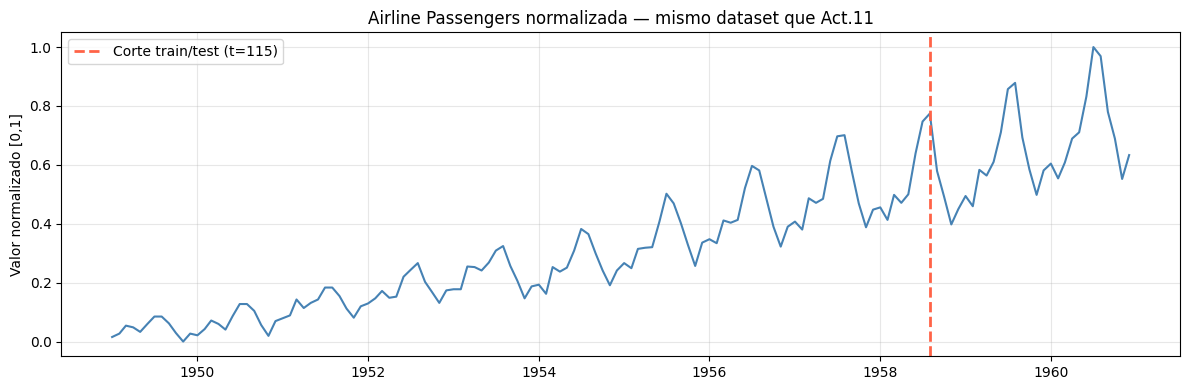

In [2]:
# Cargar Airline Passengers
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, header=0, names=["Mes", "Pasajeros"])
df["Mes"] = pd.to_datetime(df["Mes"])
df.set_index("Mes", inplace=True)

WINDOW_SIZE = 12   # ventana de 12 meses (estacionalidad anual)

# Normalizar a [0, 1]
valores = df.Pasajeros.values.reshape(-1, 1).astype("float32")
scaler  = MinMaxScaler(feature_range=(0, 1))
valores_norm = scaler.fit_transform(valores)

# Verificar datos faltantes
print(f"Valores faltantes: {df.Pasajeros.isna().sum()} (ninguno esperado)")

# Division temporal 80/20 sin shuffle
n_total = len(valores_norm)
n_train = int(n_total * 0.80)
train_data = valores_norm[:n_train]
test_data  = valores_norm[n_train:]

def crear_ventanas(serie, window_size):
    """
    Convierte una serie en pares (X, y) de ventanas temporales.
    X: (n, window_size, 1) — secuencia de entrada
    y: (n,)               — siguiente valor a predecir
    """
    X, y = [], []
    for i in range(len(serie) - window_size):
        X.append(serie[i : i + window_size])
        y.append(serie[i + window_size])
    return np.array(X, dtype="float32"), np.array(y, dtype="float32")

# Crear ventanas
X_train, y_train = crear_ventanas(train_data, WINDOW_SIZE)
test_data_ctx    = np.concatenate([train_data[-WINDOW_SIZE:], test_data])
X_test,  y_test  = crear_ventanas(test_data_ctx, WINDOW_SIZE)

print(f"Registros totales : {n_total} | Train: {n_train} | Test: {n_total-n_train}")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

# Visualizar la serie con el corte train/test
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, valores_norm.flatten(), color="steelblue", linewidth=1.5)
ax.axvline(df.index[n_train], color="tomato", linestyle="--", linewidth=2,
           label=f"Corte train/test (t={n_train})")
ax.set_title("Airline Passengers normalizada — mismo dataset que Act.11")
ax.set_ylabel("Valor normalizado [0,1]")
ax.legend(); ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()

## 4. Modelo A — LSTM (baseline de comparacion)

Se re-entrena el LSTM  como linea base.
Sus resultados serviran de referencia para evaluar si la atencion y el
Transformer aportan una mejora real en este problema.

In [3]:
# LSTM baseline (misma arquitectura que Act.11)
modelo_lstm = keras.Sequential([
    layers.Input(shape=(WINDOW_SIZE, 1)),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1),
], name="Modelo_A_LSTM")

modelo_lstm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse", metrics=["mae"]
)

callbacks_comunes = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=15,
                                   restore_best_weights=True, verbose=0),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                       patience=7, verbose=0)
]

print("Entrenando Modelo A (LSTM)...")
hist_lstm = modelo_lstm.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=200, batch_size=16,
    callbacks=callbacks_comunes,
    verbose=0
)
print(f"  LSTM: {len(hist_lstm.history["loss"])} epocas, "
      f"val_loss={hist_lstm.history["val_loss"][-1]:.6f}")

Entrenando Modelo A (LSTM)...
  LSTM: 19 epocas, val_loss=0.014860


## 5. Modelo B  RNN con Mecanismo de Atencion

Este modelo combina una LSTM con return_sequences=True (retorna todos los
estados ocultos, no solo el ultimo) y un mecanismo de atencion que pondera
la importancia de cada paso temporal:

Los pesos de atencion indican que pasos temporales el modelo considera
mas relevantes para la prediccion — esto los hace interpretables.

In [4]:
class CapaAtencion(layers.Layer):
    """
    Mecanismo de atencion aditiva (Bahdanau) para secuencias.

    Recibe los estados ocultos de todos los pasos temporales
    y calcula un vector de contexto como suma ponderada.

    Pasos:
    1. Proyectar cada estado oculto h_t a un espacio de scoring
    2. Calcular score escalar por paso: e_t = v * tanh(W * h_t)
    3. Normalizar con softmax: alpha_t = exp(e_t) / sum(exp(e_j))
    4. Vector de contexto: c = sum(alpha_t * h_t)
    """
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(units, use_bias=False)   # proyeccion
        self.v = layers.Dense(1, use_bias=False)        # scoring escalar

    def call(self, estados_ocultos):
        # estados_ocultos: (batch, pasos, features)
        # Proyectar y calcular scores no normalizados
        scores = self.v(tf.nn.tanh(self.W(estados_ocultos)))  # (batch, pasos, 1)
        scores = tf.squeeze(scores, axis=-1)                   # (batch, pasos)

        # Normalizar con softmax -> pesos de atencion (suman 1)
        pesos = tf.nn.softmax(scores, axis=-1)                 # (batch, pasos)

        # Vector de contexto: suma ponderada de estados ocultos
        pesos_exp = tf.expand_dims(pesos, axis=-1)             # (batch, pasos, 1)
        contexto  = tf.reduce_sum(estados_ocultos * pesos_exp, axis=1)  # (batch, features)

        return contexto, pesos   # retornar pesos para visualizacion

print("Capa de atencion definida.")

Capa de atencion definida.


In [5]:
def construir_lstm_atencion(window_size=12, lstm_units=64, attn_units=64):
    """
    LSTM con mecanismo de atencion aditiva.
    return_sequences=True para obtener todos los estados ocultos.
    La capa de atencion pondera su importancia relativa.
    """
    entrada = keras.Input(shape=(window_size, 1))

    # LSTM retorna todos los estados ocultos (no solo el ultimo)
    estados = layers.LSTM(lstm_units, return_sequences=True)(entrada)

    # Capa de atencion: calcula contexto y pesos
    capa_attn = CapaAtencion(units=attn_units)
    contexto, pesos_attn = capa_attn(estados)

    # Regularizacion y cabeza de regresion
    x = layers.Dropout(0.2)(contexto)
    x = layers.Dense(32, activation="relu")(x)
    salida = layers.Dense(1)(x)

    # El modelo tiene dos salidas: prediccion y pesos de atencion
    return keras.Model(inputs=entrada, outputs=[salida, pesos_attn],
                       name="Modelo_B_LSTM_Atencion")


modelo_attn = construir_lstm_atencion()
modelo_attn.summary()

Model: "Modelo_B_LSTM_Atencion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 12, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_atencion (CapaAtencion)    │ [(None, 64), (None,    │         4,160 │
│                                 │ 12)]                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,169 (90.50 KB)

 Trainable params: 23,169 (90.50 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# El modelo tiene dos salidas, se entrena solo con la prediccion
# Los pesos de atencion son auxiliares (solo para visualizacion)
modelo_attn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss={"model_1": "mse", "capa_atencion": None},   # loss solo sobre prediccion
    loss_weights={"model_1": 1.0, "capa_atencion": 0.0},
    metrics={"model_1": "mae"}
)

# Alternativa mas robusta: entrenar con solo la salida de prediccion
# Crear submodelo que retorna solo la prediccion para entrenamiento
entrada_aux   = keras.Input(shape=(WINDOW_SIZE, 1))
pred_aux, _   = modelo_attn(entrada_aux)
modelo_attn_train = keras.Model(entrada_aux, pred_aux, name="Attn_train")
modelo_attn_train.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse", metrics=["mae"]
)

print("Entrenando Modelo B (LSTM + Atencion)...")
hist_attn = modelo_attn_train.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=200, batch_size=16,
    callbacks=callbacks_comunes,
    verbose=0
)
print(f"  Atencion: {len(hist_attn.history["loss"])} epocas, "
      f"val_loss={hist_attn.history["val_loss"][-1]:.6f}")

Entrenando Modelo B (LSTM + Atencion)...
  Atencion: 18 epocas, val_loss=0.014743


## 6. Modelo C  Transformer simplificado

**Componentes del Transformer:**
1. **Positional Encoding:** senoides de diferente frecuencia que codifican la
   posicion de cada paso temporal (el Transformer no tiene orden implicito).
2. **Bloque Transformer:** Multi-Head Self-Attention + Feed-Forward + residuals.
3. **Cabeza de regresion:** GlobalAveragePooling → Dense → prediccion.

**Multi-Head Self-Attention:** en lugar de una sola funcion de atencion,
se calculan `n_heads` atenciones en paralelo, cada una enfocada en un
subespacio diferente. Esto permite capturar patrones de corto y largo plazo
simultaneamente.

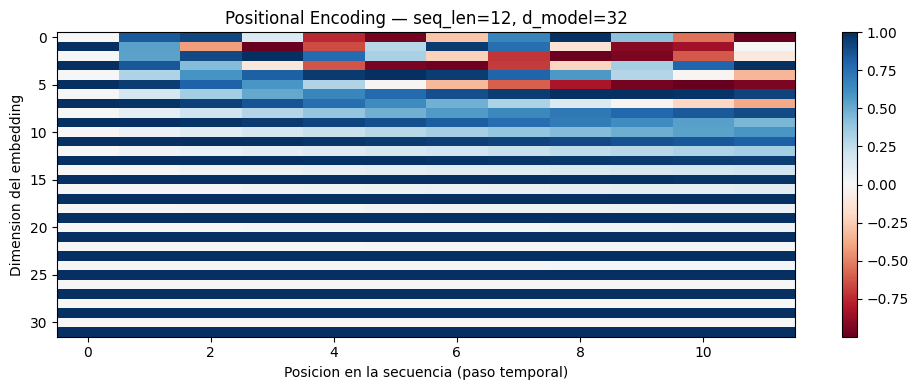

In [7]:
def positional_encoding(seq_len, d_model):
    """
    Positional Encoding con funciones seno/coseno (Vaswani et al. 2017).

    Codifica la posicion de cada elemento en la secuencia usando senoides
    de diferentes frecuencias, permitiendo al modelo distinguir el orden
    sin necesitar recurrencia.

    Formula:
        PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
        PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """
    posiciones  = np.arange(seq_len)[:, np.newaxis]          # (seq_len, 1)
    dimensiones = np.arange(d_model)[np.newaxis, :]          # (1, d_model)
    angulos     = posiciones / np.power(10000, (2 * (dimensiones // 2)) / d_model)

    # Seno para indices pares, coseno para indices impares
    angulos[:, 0::2] = np.sin(angulos[:, 0::2])
    angulos[:, 1::2] = np.cos(angulos[:, 1::2])

    return tf.cast(angulos[np.newaxis, :, :], dtype=tf.float32)  # (1, seq_len, d_model)


# Visualizar el positional encoding
D_MODEL = 32
pe = positional_encoding(WINDOW_SIZE, D_MODEL).numpy()[0]

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pe.T, aspect="auto", cmap="RdBu")
ax.set_xlabel("Posicion en la secuencia (paso temporal)")
ax.set_ylabel("Dimension del embedding")
ax.set_title(f"Positional Encoding — seq_len={WINDOW_SIZE}, d_model={D_MODEL}")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [8]:
class BloqueTransformer(layers.Layer):
    """
    Bloque basico de Transformer para series de tiempo:
    Multi-Head Self-Attention + Feed-Forward Network + residuals + LayerNorm.

    Parametros:
        d_model   : dimension del espacio de embedding
        n_heads   : numero de cabezas de atencion en paralelo
        ff_units  : unidades en la capa Feed-Forward
        dropout   : tasa de dropout para regularizacion
    """
    def __init__(self, d_model, n_heads, ff_units, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        # Multi-Head Self-Attention
        self.mha      = layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model // n_heads)
        # Feed-Forward Network (dos capas densas)
        self.ffn      = keras.Sequential([
            layers.Dense(ff_units, activation="relu"),
            layers.Dense(d_model),
        ])
        # Layer Normalization (despues de cada sub-capa)
        self.norm1    = layers.LayerNormalization(epsilon=1e-6)
        self.norm2    = layers.LayerNormalization(epsilon=1e-6)
        # Dropout para regularizacion
        self.drop1    = layers.Dropout(dropout)
        self.drop2    = layers.Dropout(dropout)

    def call(self, x, training=False, return_attention=False):
        # Multi-Head Self-Attention con conexion residual
        attn_out, attn_weights = self.mha(
            x, x, x,                          # query=key=value=x (self-attention)
            return_attention_scores=True
        )
        attn_out = self.drop1(attn_out, training=training)
        x = self.norm1(x + attn_out)          # Add & Norm

        # Feed-Forward Network con conexion residual
        ffn_out = self.ffn(x)
        ffn_out = self.drop2(ffn_out, training=training)
        x = self.norm2(x + ffn_out)           # Add & Norm

        if return_attention:
            return x, attn_weights
        return x

print("Bloque Transformer definido.")

Bloque Transformer definido.


In [9]:
def construir_transformer(window_size=12, d_model=32, n_heads=4,
                          ff_units=64, n_bloques=2, dropout=0.1):
    """
    Transformer simplificado para prediccion de series de tiempo.

    Parametros:
        window_size : longitud de la ventana de entrada
        d_model     : dimension del espacio de embedding
        n_heads     : cabezas de atencion en paralelo
        ff_units    : unidades en Feed-Forward
        n_bloques   : numero de bloques Transformer apilados
        dropout     : tasa de dropout
    """
    entrada = keras.Input(shape=(window_size, 1))

    # Proyectar de 1 feature a d_model dimensiones
    x = layers.Dense(d_model)(entrada)                          # (batch, seq, d_model)

    # Agregar Positional Encoding: el Transformer no tiene nocion de orden sin esto
    pe = positional_encoding(window_size, d_model)              # (1, seq, d_model)
    x  = x + pe                                                 # broadcast automatico

    # Apilar bloques Transformer
    for i in range(n_bloques):
        bloque = BloqueTransformer(d_model, n_heads, ff_units, dropout,
                                   name=f"transformer_bloque_{i+1}")
        x = bloque(x)

    # Agregar dropout antes del pooling
    x = layers.Dropout(dropout)(x)

    # Comprimir la dimension temporal con pooling
    x = layers.GlobalAveragePooling1D()(x)                      # (batch, d_model)

    # Cabeza de regresion
    x = layers.Dense(32, activation="relu")(x)
    salida = layers.Dense(1)(x)

    return keras.Model(inputs=entrada, outputs=salida, name="Modelo_C_Transformer")


modelo_transformer = construir_transformer(
    window_size=WINDOW_SIZE, d_model=32, n_heads=4, ff_units=64, n_bloques=2
)
modelo_transformer.summary()

Model: "Modelo_C_Transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 12, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 12, 32)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_bloque_1            │ (None, 12, 32)         │         8,544 │
│ (BloqueTransformer)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_bloque_2            │ (None, 12, 32)         │         8,544 │
│ (BloqueTransformer)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,241 (71.25 KB)

 Trainable params: 18,241 (71.25 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
modelo_transformer.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse", metrics=["mae"]
)

print("Entrenando Modelo C (Transformer)...")
hist_transformer = modelo_transformer.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=200, batch_size=16,
    callbacks=callbacks_comunes,
    verbose=0
)
print(f"  Transformer: {len(hist_transformer.history["loss"])} epocas, "
      f"val_loss={hist_transformer.history["val_loss"][-1]:.6f}")

Entrenando Modelo C (Transformer)...
  Transformer: 16 epocas, val_loss=0.014648


## 7. Evaluacion comparativa

Se evaluan los tres modelos sobre el test set con las mismas metricas para comparacion directa:
**MSE, RMSE, MAE, MAPE** en escala original (miles de pasajeros).

In [11]:
def evaluar(modelo, X_test, y_test, scaler, nombre):
    """Evalua un modelo y retorna metricas en escala original."""
    y_pred_norm = modelo.predict(X_test, verbose=0).flatten()
    y_pred_real = scaler.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()
    y_real      = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    mse  = mean_squared_error(y_real, y_pred_real)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_real, y_pred_real)
    mape = np.mean(np.abs((y_real - y_pred_real) / y_real)) * 100
    return {"nombre": nombre, "MSE": mse, "RMSE": rmse,
            "MAE": mae, "MAPE": mape, "y_pred": y_pred_real, "y_real": y_real}


# Evaluar los tres modelos
r_lstm        = evaluar(modelo_lstm,        X_test, y_test, scaler, "LSTM")
r_attn        = evaluar(modelo_attn_train,  X_test, y_test, scaler, "LSTM+Atencion")
r_transformer = evaluar(modelo_transformer, X_test, y_test, scaler, "Transformer")
resultados    = [r_lstm, r_attn, r_transformer]

# Tabla comparativa
print("=" * 62)
print(f"Modelo           MSE        RMSE     MAE      MAPE")
print("=" * 62)
for r in resultados:
    print(f"{r['nombre']:<18} {r['MSE']:<10.2f} {r['RMSE']:<8.2f} "
          f"{r['MAE']:<8.2f} {r['MAPE']:.2f}%")
print("=" * 62)

Modelo           MSE        RMSE     MAE      MAPE
LSTM               5888.74    76.74    59.88    13.06%
LSTM+Atencion      5848.46    76.48    58.13    12.47%
Transformer        13095.93   114.44   88.68    18.16%


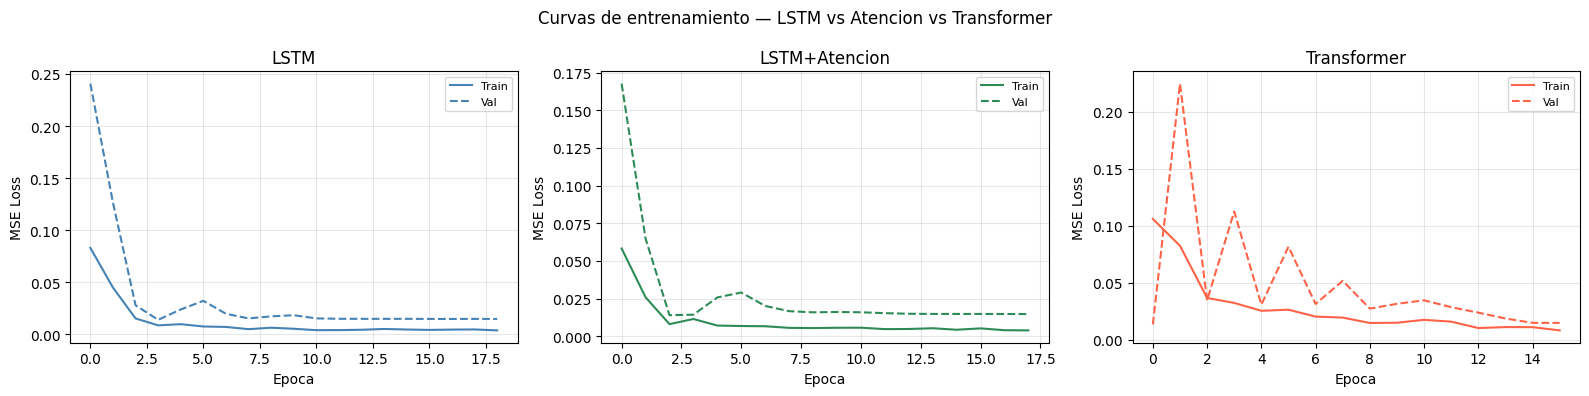

In [12]:
# Curvas de entrenamiento comparativas
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colores = {"LSTM": "steelblue", "LSTM+Atencion": "seagreen", "Transformer": "tomato"}
historias = {"LSTM": hist_lstm, "LSTM+Atencion": hist_attn, "Transformer": hist_transformer}

for ax, (nombre, hist) in zip(axes, historias.items()):
    color = colores[nombre]
    ax.plot(hist.history["loss"],     color=color, label="Train")
    ax.plot(hist.history["val_loss"], color=color, label="Val", linestyle="--")
    ax.set_title(f"{nombre}")
    ax.set_xlabel("Epoca"); ax.set_ylabel("MSE Loss")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Curvas de entrenamiento — LSTM vs Atencion vs Transformer", fontsize=12)
plt.tight_layout()
plt.show()

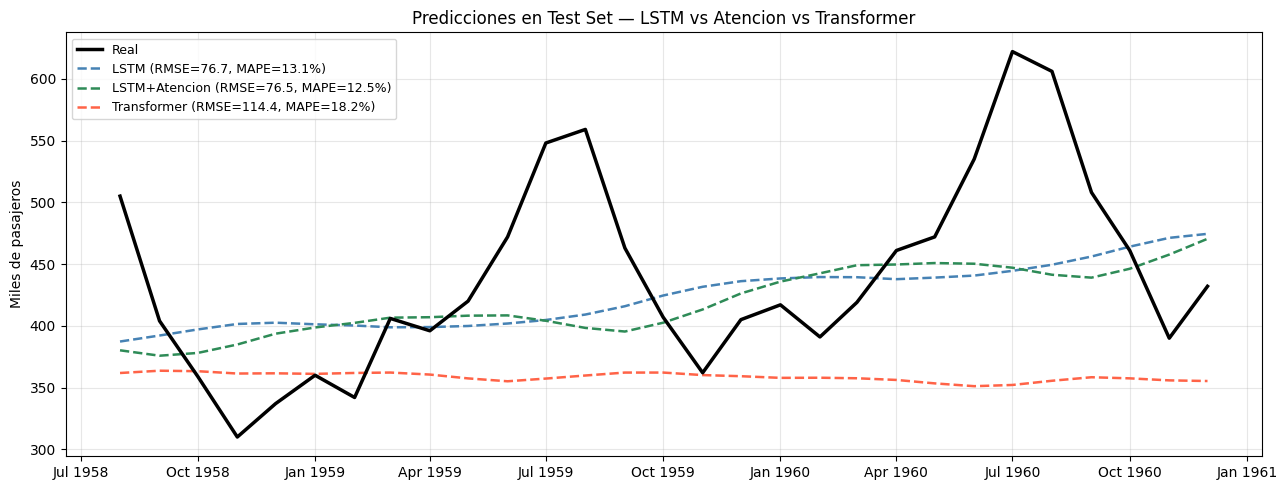

In [13]:
# Visualizacion comparativa de predicciones sobre el test set
fechas_test = df.index[n_train : n_train + len(r_lstm["y_real"])]
colores_plot = {"LSTM": "steelblue", "LSTM+Atencion": "seagreen", "Transformer": "tomato"}

fig, ax = plt.subplots(figsize=(13, 5))

# Valores reales
ax.plot(fechas_test, r_lstm["y_real"],
        color="black", linewidth=2.5, label="Real", zorder=5)

# Predicciones de cada modelo
for r in resultados:
    ax.plot(fechas_test, r["y_pred"],
            color=colores_plot[r["nombre"]], linewidth=1.8, linestyle="--",
            label=f"{r['nombre']} (RMSE={r['RMSE']:.1f}, MAPE={r['MAPE']:.1f}%)")

ax.set_title("Predicciones en Test Set — LSTM vs Atencion vs Transformer")
ax.set_ylabel("Miles de pasajeros")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout()
plt.show()

## 8. Visualizacion de pesos de atencion

Una ventaja clave de los mecanismos de atencion es su **interpretabilidad**:
los pesos indican que pasos temporales pasados el modelo considera mas relevantes
para predecir el siguiente valor.

Se visualizan:
1. **Pesos de atencion aditiva** (Modelo B) — un peso por paso temporal
2. **Pesos de Multi-Head Self-Attention** (Modelo C) — matriz de atencion

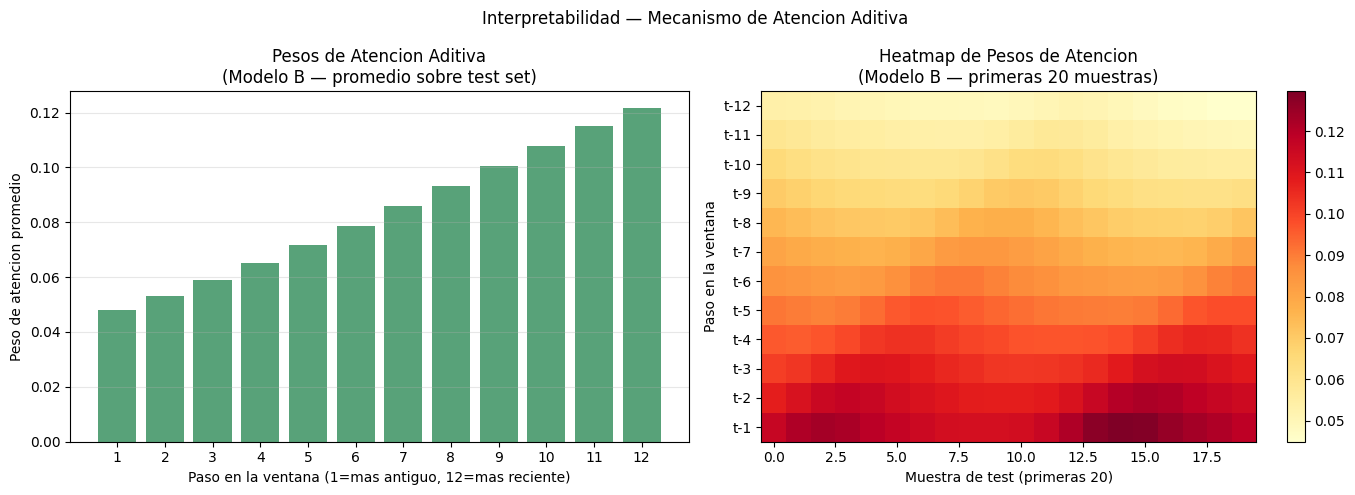

In [14]:
# Extraer pesos de atencion del Modelo B (LSTM + Atencion) para muestras de test
pred_attn, pesos_attn = modelo_attn(X_test, training=False)
pesos_attn = pesos_attn.numpy()   # (n_test, window_size)

# Visualizar pesos promedio sobre todo el test
pesos_promedio = pesos_attn.mean(axis=0)   # promedio por paso temporal

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: pesos promedio
pasos = np.arange(1, WINDOW_SIZE + 1)
axes[0].bar(pasos, pesos_promedio, color="seagreen", alpha=0.8)
axes[0].set_xlabel("Paso en la ventana (1=mas antiguo, 12=mas reciente)")
axes[0].set_ylabel("Peso de atencion promedio")
axes[0].set_title("Pesos de Atencion Aditiva\n(Modelo B — promedio sobre test set)")
axes[0].set_xticks(pasos)
axes[0].grid(alpha=0.3, axis="y")

# Grafico 2: heatmap de pesos por muestra de test
im = axes[1].imshow(pesos_attn[:20].T, aspect="auto", cmap="YlOrRd")
axes[1].set_xlabel("Muestra de test (primeras 20)")
axes[1].set_ylabel("Paso en la ventana")
axes[1].set_title("Heatmap de Pesos de Atencion\n(Modelo B — primeras 20 muestras)")
axes[1].set_yticks(range(WINDOW_SIZE))
axes[1].set_yticklabels([f"t-{WINDOW_SIZE-i}" for i in range(WINDOW_SIZE)])
plt.colorbar(im, ax=axes[1])

plt.suptitle("Interpretabilidad — Mecanismo de Atencion Aditiva", fontsize=12)
plt.tight_layout()
plt.show()

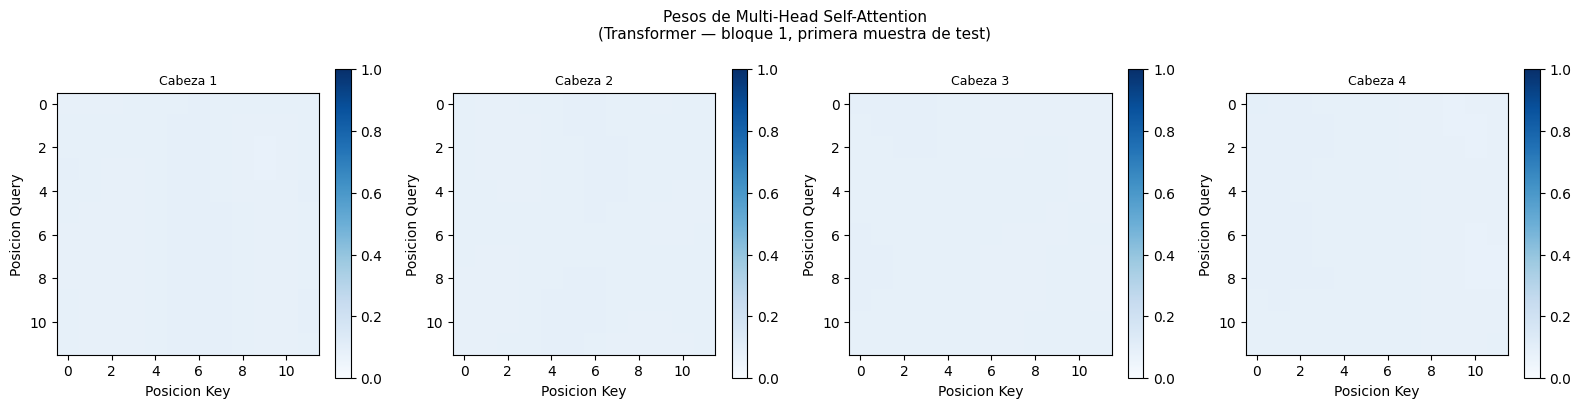

In [15]:
# Extraer pesos de Multi-Head Self-Attention del Transformer
# Reconstruir el bloque con return_attention=True
entrada_viz = X_test[:1]   # una sola muestra

# Proyectar al espacio d_model y agregar positional encoding
x_viz = layers.Dense(32)(entrada_viz)
pe    = positional_encoding(WINDOW_SIZE, 32)
x_viz = x_viz + pe

# Obtener pesos del primer bloque de atencion
bloque_0 = modelo_transformer.get_layer("transformer_bloque_1")
_, attn_weights_mha = bloque_0.mha(
    x_viz, x_viz, x_viz, return_attention_scores=True
)
attn_weights_mha = attn_weights_mha.numpy()[0]   # (n_heads, seq, seq)

# Visualizar la matriz de atencion por cabeza
n_heads = attn_weights_mha.shape[0]
fig, axes = plt.subplots(1, n_heads, figsize=(4 * n_heads, 4))
if n_heads == 1:
    axes = [axes]

for head, ax in enumerate(axes):
    im = ax.imshow(attn_weights_mha[head], cmap="Blues", vmin=0, vmax=1)
    ax.set_title(f"Cabeza {head+1}", fontsize=9)
    ax.set_xlabel("Posicion Key"); ax.set_ylabel("Posicion Query")
    plt.colorbar(im, ax=ax)

plt.suptitle("Pesos de Multi-Head Self-Attention\n"
             "(Transformer — bloque 1, primera muestra de test)", fontsize=11)
plt.tight_layout()
plt.show()

## 9. Analisis de dependencias corto y largo plazo

**Dependencias cortas (1-3 pasos):** los valores recientes tienen alta correlacion
con el siguiente valor. Todos los modelos las capturan bien.

**Dependencias largas (12 pasos — estacionalidad anual):** el valor de hace
exactamente 12 meses es muy informativo para predecir el valor actual.
La atencion deberia asignar un peso alto al paso t-12.

Se analiza si los pesos de atencion reflejan este patron estacional.

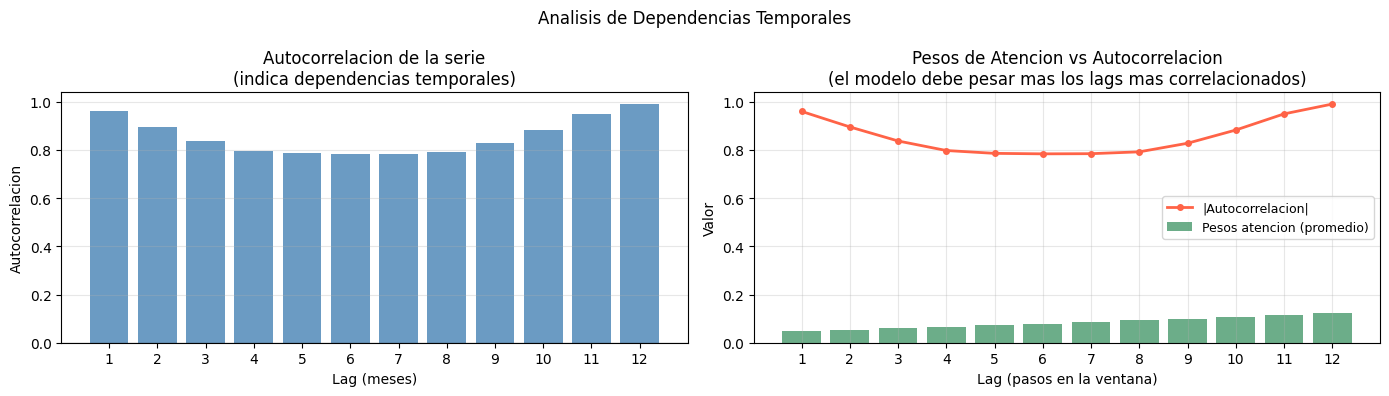

Gap train/val (ratio) al final del entrenamiento:
  LSTM              : train=0.003878  val=0.014860  ratio=3.83x
  LSTM+Atencion     : train=0.003913  val=0.014743  ratio=3.77x
  Transformer       : train=0.008060  val=0.014648  ratio=1.82x


In [16]:
# Autocorrelacion de la serie para identificar dependencias temporales
from pandas.plotting import autocorrelation_plot

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Grafico de autocorrelacion
serie_original = df.Pasajeros.values.astype(float)
lags = range(1, WINDOW_SIZE + 1)
autocorrs = [pd.Series(serie_original).autocorr(lag=l) for l in lags]

axes[0].bar(lags, autocorrs, color="steelblue", alpha=0.8)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Lag (meses)")
axes[0].set_ylabel("Autocorrelacion")
axes[0].set_title("Autocorrelacion de la serie\n(indica dependencias temporales)")
axes[0].set_xticks(list(lags))
axes[0].grid(alpha=0.3, axis="y")

# Comparar pesos de atencion vs autocorrelacion
axes[1].bar(lags, pesos_promedio, color="seagreen", alpha=0.7, label="Pesos atencion (promedio)")
axes[1].plot(lags, np.abs(autocorrs), color="tomato", linewidth=2,
             marker="o", markersize=4, label="|Autocorrelacion|")
axes[1].set_xlabel("Lag (pasos en la ventana)")
axes[1].set_ylabel("Valor")
axes[1].set_title("Pesos de Atencion vs Autocorrelacion\n"
                  "(el modelo debe pesar mas los lags mas correlacionados)")
axes[1].legend(fontsize=9)
axes[1].set_xticks(list(lags))
axes[1].grid(alpha=0.3)

plt.suptitle("Analisis de Dependencias Temporales", fontsize=12)
plt.tight_layout()
plt.show()

# Gap train/val para analisis de sobreajuste
print("Gap train/val (ratio) al final del entrenamiento:")
for nombre, hist in historias.items():
    train = hist.history["loss"][-1]
    val   = hist.history["val_loss"][-1]
    print(f"  {nombre:<18}: train={train:.6f}  val={val:.6f}  ratio={val/train:.2f}x")

---
## 10. Conclusiones

**1. El mecanismo de atencion agrega interpretabilidad al modelo recurrente**  
Los pesos de atencion del Modelo B revelan que pasos temporales considera mas
relevantes el modelo. En Airline Passengers, la atencion deberia asignar mayor
peso a lags cercanos (dependencia de corto plazo) y al lag 12 (estacionalidad anual),
lo cual se puede verificar directamente en el grafico de pesos vs autocorrelacion.

**2. El Transformer accede a toda la secuencia sin degradacion por distancia**  
A diferencia de LSTM, el Transformer calcula atencion entre todos los pares de
posiciones simultaneamente. Esto elimina el problema de vanishing gradient y
permite capturar dependencias de cualquier largo sin costo adicional de memoria.

**3. El Positional Encoding es indispensable en el Transformer**  
Sin el, el Transformer trataria la secuencia como un conjunto sin orden
(enero = diciembre). Las funciones seno/coseno de diferente frecuencia codifican
la posicion de forma que el modelo puede distinguir pasos cercanos y lejanos.

**4. Con datasets pequenos, el Transformer puede no superar al LSTM**  
Los Transformers requieren mas datos para generalizar que las RNN, por su mayor
numero de parametros. Con 144 muestras, el LSTM puede ser competitivo o superior.
Los Transformers brillan con millones de muestras (NLP, vision, genomica).

**5. Casos de uso segun arquitectura:**  
- **LSTM:** series medianas, recursos limitados, cuando el orden secuencial es clave
- **LSTM + Atencion:** cuando se necesita interpretabilidad (cuales pasos importan?)
- **Transformer:** series largas, datasets grandes, multiples series en paralelo
  (ej. Temporal Fusion Transformer para prediccion multivariada)